## ** 코드 마지막 까지 다 돌려보았습니다! **

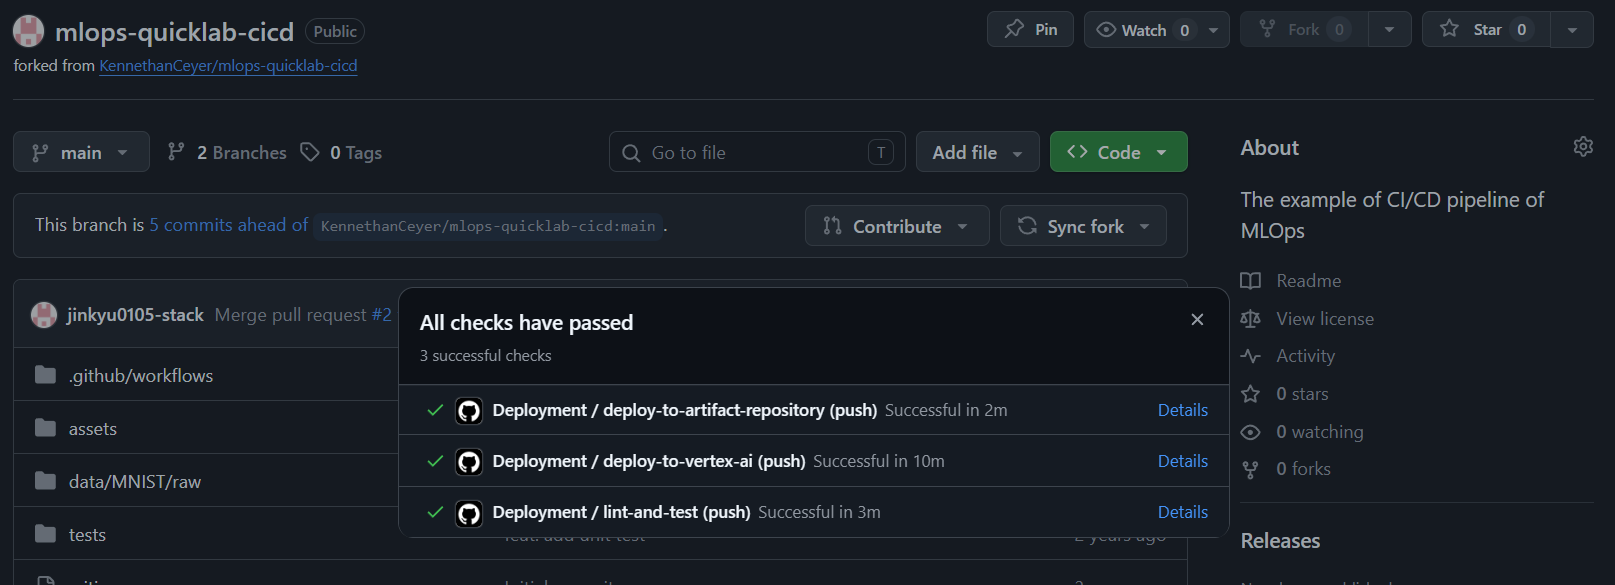

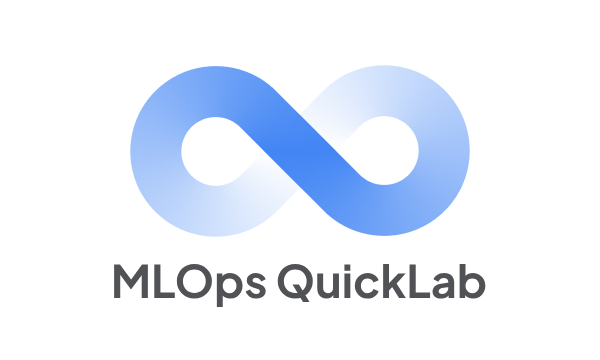

4. Vertex AI 소개 및 개요

In [ ]:
!pip install datasets torchserve torch-model-archiver torch-workflow-archiver nvgpu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.1 MB/s eta 0:00:00
  Created wheel for nvgpu: filename=nvgpu-0.10.0-py3-none-any.whl size=9544 sha256=0743e4ec37561524915670804eb04bee1d4f01a7c90a6b9864ea9ad8cf233f06
  Stored in directory: /root/.cache/pip/wheels/6e/4a/5d/db9b77ea9d1981efbe7a03a10318930d6c5897c85f751d52dc
Successfully built nvgpu


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import seaborn as sns

from torch.utils.data import DataLoader
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import confusion_matrix
from datasets import load_dataset
from tqdm import tqdm
from typing import TypedDict
import matplotlib.pyplot as plt

In [ ]:
dataset = load_dataset("ag_news")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
optimizer = AdamW(model.parameters(), lr=5e-5)
criterion = torch.nn.CrossEntropyLoss()

class DatasetItem(TypedDict):
    text: str
    label: str


def preprocess_data(dataset_item: DatasetItem) -> dict[str, torch.Tensor]:
    return tokenizer(dataset_item["text"], truncation=True, padding="max_length", return_tensors="pt")


train_dataset = dataset["train"].select(range(1200)).map(preprocess_data, batched=True)
test_dataset = dataset["test"].select(range(800)).map(preprocess_data, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 3
losses: list[float] = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}, Average Loss: {average_loss}")

Epoch 1: 100%|██████████| 150/150 [01:46<00:00,  1.41it/s]


Epoch 1, Average Loss: 0.634128707498312


Epoch 2: 100%|██████████| 150/150 [02:03<00:00,  1.21it/s]


Epoch 2, Average Loss: 0.28823311048249406


Epoch 3: 100%|██████████| 150/150 [02:05<00:00,  1.20it/s]

Epoch 3, Average Loss: 0.1630105647755166


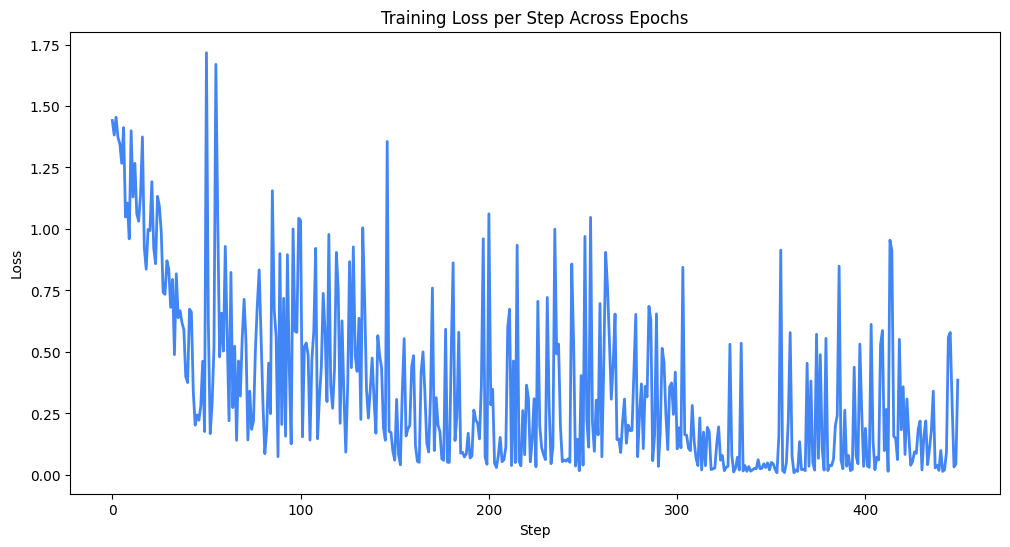

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(losses, color="#4285f4", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss per Step Across Epochs")
plt.show()

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Evaluating: 100%|██████████| 100/100 [00:28<00:00,  3.53it/s]


Test Accuracy: 84.88%


In [ ]:
test_input = "[Official] 'Legendary Coach Resigns → Appoints New Commander' Suwon Completes Coaching Staff... Scout Bae Ki-jong Joins + Coach Shin Hwa-yong Remains"
test_input_processed = tokenizer(test_input, truncation=True, padding="max_length", return_tensors="pt").to(device)
logits = model(**test_input_processed).logits
print(logits)
predicted_labels = torch.argmax(logits, dim=1)

labeling_mapper = ["world", "sports", "business", "sci/tech"]
print(labeling_mapper[predicted_labels[0]])

tensor([[ 0.3502,  4.7486, -2.0391, -2.1546]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
sports


In [ ]:
all_predictions: list[int] = []
all_labels: list[int] = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)

        all_predictions.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating: 100%|██████████| 100/100 [00:28<00:00,  3.49it/s]


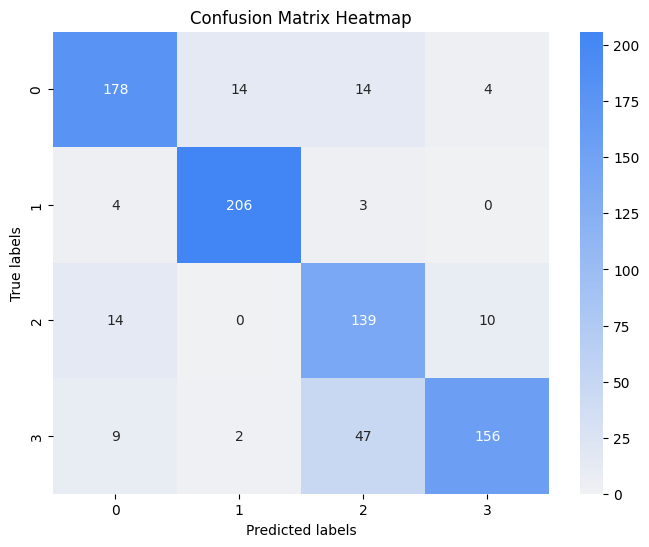

In [ ]:
conf_matrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap=sns.light_palette("#4285f4", as_cmap=True))
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

## TorchServe Archive

In [ ]:
# 모델 체크포인트 저장.
model_save_path = "model.pth"
torch.save(model.state_dict(), model_save_path)

In [ ]:
%%writefile handler.py
import json
import logging

import torch
from ts.context import Context
from ts.torch_handler.base_handler import BaseHandler
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification

logging.basicConfig(level=logging.INFO)

class ModelHandler(BaseHandler):
    def __init__(self):
        self.initialized = False
        self.tokenizer = None
        self.model = None

    def initialize(self, context: Context):
        properties = context.system_properties
        model_dir = properties.get("model_dir")
        self.initialized = True
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
        model_path = model_dir + "/model.pth"
        self.model.load_state_dict(torch.load(model_path))
        self.model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
        self.model.eval()

    def preprocess(self, texts: list[str]) -> BatchEncoding:
        logging.info("preprocess", texts)

        inputs = self.tokenizer(texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return inputs.to(device)

    def inference(self, input_batch: BatchEncoding) -> torch.Tensor:
        with torch.no_grad():
            outputs = self.model(**input_batch)
            logging.info("inference", outputs)
            return outputs.logits

    def postprocess(self, inference_output: torch.Tensor) -> list[dict[str, float]]:
        logging.info("postprocess", inference_output)

        probabilities = torch.nn.functional.softmax(inference_output, dim=1)
        return [{"label": int(torch.argmax(prob)), "probability": float(prob.max())} for prob in probabilities]

Writing handler.py


In [ ]:
# bert vocab 파일 (아티팩트)

!wget https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt \
    -O bert-base-uncased-vocab.txt

--2026-04-20 09:12:07--  https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231508 (226K) [text/plain]
Saving to: ‘bert-base-uncased-vocab.txt’

bert-base-uncased-v 100%[===================>] 226.08K  --.-KB/s    in 0.02s   

2026-04-20 09:12:08 (12.2 MB/s) - ‘bert-base-uncased-vocab.txt’ saved [231508/231508]



In [ ]:
# Torch serve archiver의 최종 파일 저장 위치.
# .mar 확장자 파일을 생성하여 패키징 하게 된다.

!mkdir -p model-store

## Register to Vertex AI

In [ ]:
!torch-model-archiver \
    --model-name model \
    --version 1.0 \
    --serialized-file model.pth \
    --handler ./handler.py \
    --extra-files "bert-base-uncased-vocab.txt" \
    --export-path model-store \
    -f

In [ ]:
# from google.colab import auth
# auth.authenticate_user()

In [ ]:
from google.cloud import storage, aiplatform
from google.oauth2 import service_account

In [ ]:
credentials = service_account.Credentials.from_service_account_file("credentials.json")

In [ ]:
PROJECT_ID = "gen-lang-client-0631347961"                    # @param {type: "string"}
LOCATION = "asia-northeast3"                                       # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab-0"   # @param {type: "string"}
MODEL_FILE_NAME = "model.mar"              # @param {type: "string"}

In [ ]:
storage_client = storage.Client(credentials=credentials)
bucket = storage_client.bucket(BUCKET_NAME)

In [ ]:
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [ ]:
upload_blob("model-store/model.mar", f"models/{MODEL_FILE_NAME}")

File model-store/model.mar uploaded to models/model.mar.


In [ ]:
aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
    credentials=credentials,
)

In [ ]:
model_path = f"gs://{BUCKET_NAME}/models"
registry_model = aiplatform.Model.upload(
    display_name="AG News Classification",
    artifact_uri=model_path,
    serving_container_image_uri="asia-northeast3-docker.pkg.dev/gen-lang-client-0631347961/mlops-quicklab/trainer:1.0.0",
    is_default_version=True,
    version_aliases=["v1"],
    version_description="A news category classification model",
    serving_container_predict_route="/predictions/model",
    serving_container_health_route="/ping",
)

In [ ]:
DEPLOY_COMPUTE = "n1-standard-2"
DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

In [ ]:
endpoint = aiplatform.Endpoint.create(
    display_name="ag-news-category-classification",
    project=PROJECT_ID,
    location=LOCATION,
)

In [ ]:
deployment = registry_model.deploy(
    endpoint=endpoint,
    machine_type=DEPLOY_COMPUTE,
    min_replica_count=1,
    max_replica_count=1,
    accelerator_type=DEPLOY_ACCELERATOR,
    accelerator_count=1,
    traffic_percentage=100,
    sync=True,
)

In [ ]:
endpoint.predict(instances=[
    "OpenAI releases AI video generator Sora to all customers"
])

Prediction(predictions=[{'probability': 0.9565587639808655, 'label': 3.0}], deployed_model_id='3456541301309177856', metadata=None, model_version_id='1', model_resource_name='projects/755790449124/locations/asia-northeast3/models/3705684039093452800', explanations=None)

## Clean up

In [ ]:
endpoint.undeploy_all()
endpoint.delete()

In [ ]:
registry_model.delete()